# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 2. Load Dataset

In [2]:
df = pd.read_csv('../data/Delhi_AQIBulletins.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:\n", df.columns)

Columns:
 Index(['date', 'city', 'no. stations', 'air quality', 'index value',
       'prominent pollutant'],
      dtype='object')


# 3. Basic Info

In [3]:
print("\nDataset Info:\n")
print(df.info())

print("\nStatistical Summary:\n")
print(df.describe())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3143 entries, 0 to 3142
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 3143 non-null   object 
 1   city                 3143 non-null   object 
 2   no. stations         3130 non-null   float64
 3   air quality          3143 non-null   object 
 4   index value          3143 non-null   int64  
 5   prominent pollutant  3143 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 147.5+ KB
None

Statistical Summary:

       no. stations  index value
count   3130.000000  3143.000000
mean      24.442812   217.135857
std       12.862081   104.011419
min        1.000000    41.000000
25%        9.000000   127.000000
50%       31.000000   209.000000
75%       35.000000   296.000000
max       39.000000   497.000000


# 4. Data Cleaning

In [4]:
# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Sort data
df = df.sort_values('date')

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Fill missing AQI values (forward fill)
df['index value'] = df['index value'].fillna(method='ffill')

# Drop rows where date is missing
df = df.dropna(subset=['date'])


Missing Values:
 date                    0
city                    0
no. stations           13
air quality             0
index value             0
prominent pollutant     0
dtype: int64


C:\Users\gprab\AppData\Local\Temp\ipykernel_34212\179612541.py:11: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['index value'] = df['index value'].fillna(method='ffill')


# 5. Time-Series Trend Plot

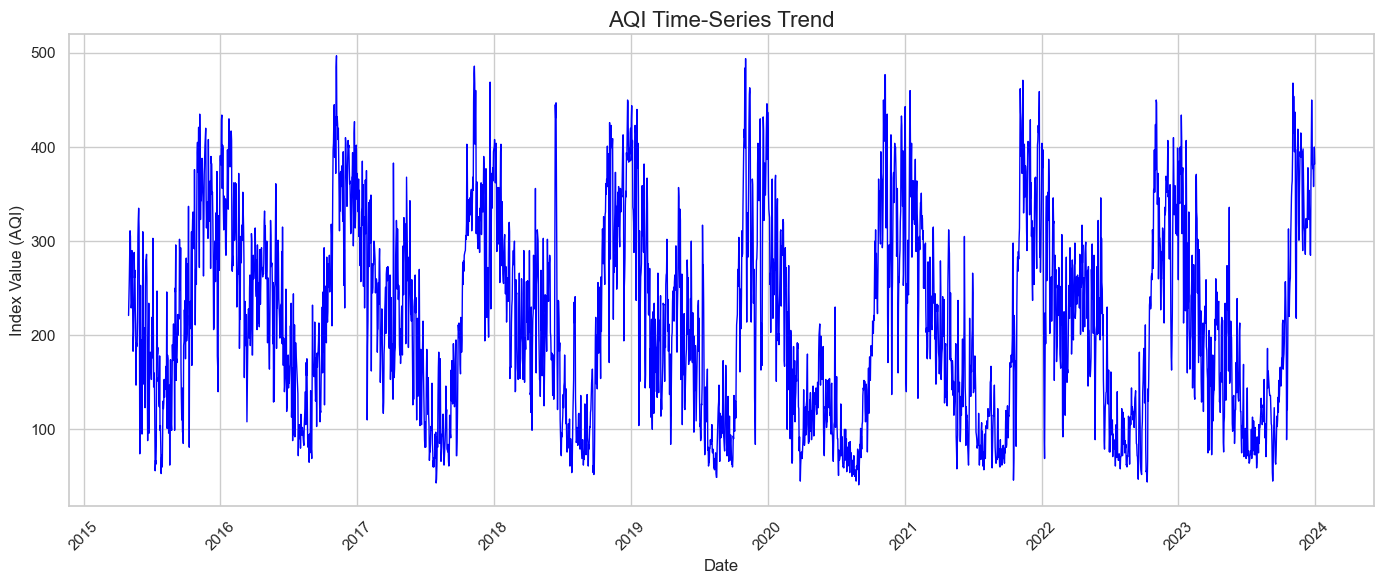

In [7]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['index value'], color='blue', linewidth=1)

plt.title("AQI Time-Series Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Index Value (AQI)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 6. Detect Abnormal Readings (Outliers)

In [9]:
Q1 = df['index value'].quantile(0.25)
Q3 = df['index value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['index value'] < lower_bound) | (df['index value'] > upper_bound)]

print("\nNumber of abnormal readings:", len(outliers))


Number of abnormal readings: 0


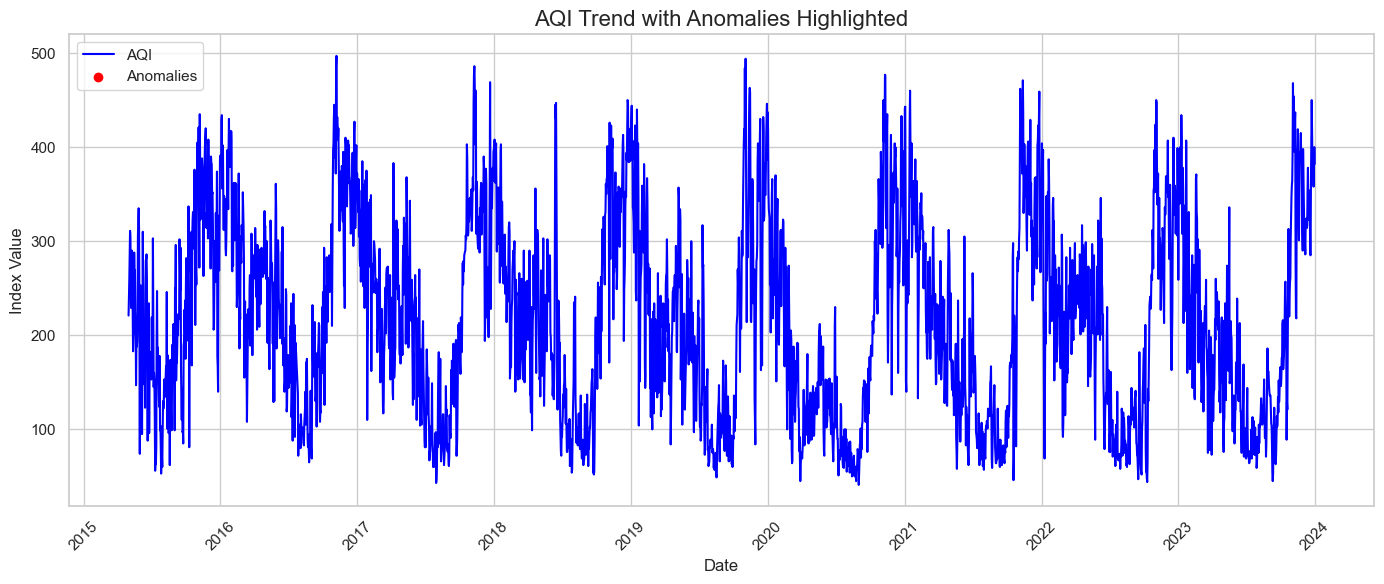

In [10]:
# Highlight outliers in plot
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['index value'], label='AQI', color='blue')
plt.scatter(outliers['date'], outliers['index value'], color='red', label='Anomalies')

plt.title("AQI Trend with Anomalies Highlighted", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Distribution of Prominent Pollutant

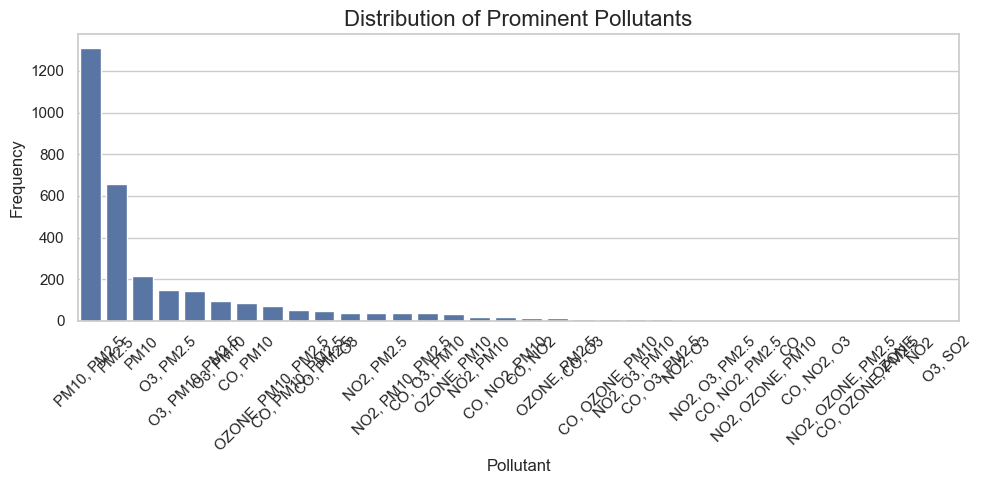

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='prominent pollutant', order=df['prominent pollutant'].value_counts().index)

plt.title("Distribution of Prominent Pollutants", fontsize=16)
plt.xlabel("Pollutant")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. AQI Distribution

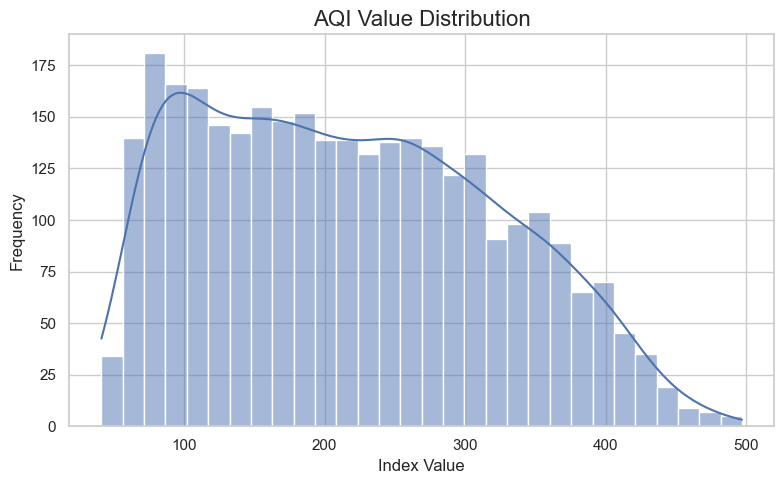

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['index value'], bins=30, kde=True)

plt.title("AQI Value Distribution", fontsize=16)
plt.xlabel("Index Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

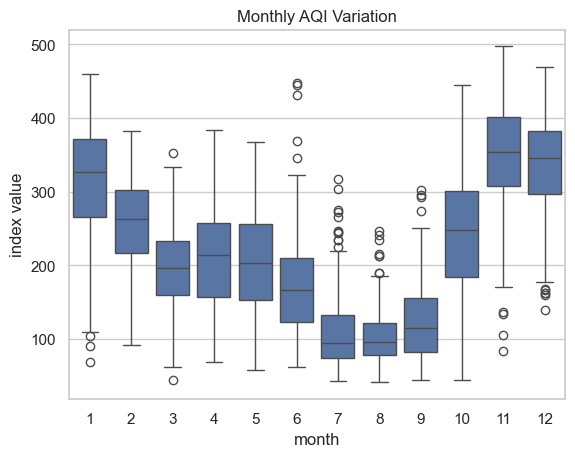

In [18]:
# Monthly trend (bonus)
df['month'] = df['date'].dt.month

sns.boxplot(x='month', y='index value', data=df)
plt.title("Monthly AQI Variation")
plt.show()